# Projeto Final


## Descrição do projeto

A finalidade do presente projeto é a criação de um modelo de predição do diagnóstico de Hipertiroidismo. A seguir serão apresentadas cada uma das quatro etapas desse desenvolvimento: exploração e preparação dos dados, análise exploratória, seleção e avaliação de modelos e comunicação dos resultado.

Na primeira etapa, exploração e preparação dos dados, estão descritos as correções aplicadas à base de dados. Por vezes, essas correções podem influenciar no resultado final, sendo importante conhecermos o tratamento de dados para compreender o resultado final. A seguir, na etapa de análise exploratória, uma análise visual e estatística dos dados será explorada. Na terceira etapa, serão discutidos as opções de modelo que melhor se adequam aos objetivos do projeto, os modelos serão então criados e avaliados. Por fim, o desempenho dos modelos e demais resultados serão apresentados.



### Configuração de bibliotecas e dados

In [3]:
import pandas as pd
import re
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import random
from sklearn.metrics import recall_score, accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score, precision_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
pd.set_option('future.no_silent_downcasting', True)

In [4]:
data = pd.read_csv('dados.csv')


## Exploração e Preparação dos dados

Abaixo está um resumo dos dados do projeto. São 30 variáveis, em um data frame com 3772 linhas, sem valores nulos. Todas as variáveis são do tipo objeto, mesmo as numéricas. Numa avaliação preliminar do conteúdo dos dados, percebe-se alguns dados faltantes marcados com  '?'.
Assim, as primeiras ações no banco de dados serão:
- Corrigir valores faltantes ("?").
- Corrigir os tipos de dados.
    - Transformar categorias quantitativas em variáveis numéricas.
    - Transformar categorias binárias em númericas (0/1).
    - Transformar categorias categóricas em classes numéricas. 

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

In [6]:
print(f'Tamanho total do dataframe: {len(data)}')

Tamanho total do dataframe: 3772


In [7]:
print("Categorias ocm valores nulos: ")
temp = data.isnull().sum()
for i,n in enumerate(temp):
     if n > 0: print(f"{i}: {n}")

Categorias ocm valores nulos: 


In [8]:
print("Vizualização inicial dos dados: ")
data.head()

Vizualização inicial dos dados: 


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


In [9]:
tipo_var=['number', 'int64', 'float', 'bool', 'object', 'string']
print(f'Número de variáveis do tipo')
for i in tipo_var:
    print(f'{i}: {data.dtypes[data.dtypes == i].count()}')


Número de variáveis do tipo
number: 0
int64: 0
float: 0
bool: 0
object: 30
string: 0


#### Para transformar os valores de maneira adequada, primeiro serão identificados qual deveria ser o tipo de cada categoria. Depois, todas as variáveis serão transformadas em numéricas, com os devidos métodos aplicados a cada uma.

In [10]:
column_number = []
column_letters = []
column_others = []

for i in data.columns:
    amostra = data[i].iloc[0]

    if re.match(r'^\d+$', str(amostra)):
        column_number.append(i)
    
    elif re.match(r'^[a-zA-Z]+$', str(amostra)):
        column_letters.append(i)

    else:
        column_others.append(i)

print("Colunas numéricas:", column_number)
print("Colunas com letras:", column_letters)
print("Outras colunas:", column_others)


Colunas numéricas: ['age', 'TT4', 'FTI']
Colunas com letras: ['sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured', 'referral source', 'binaryClass']
Outras colunas: ['TSH', 'T3', 'T4U', 'TBG']


#### As variáveis TSH', 'T3', 'T4U', 'TBG' foram classificados como "outros", afim de compreender melhor o que isso significa, os seus valores foram investigados em mais detalhes.


In [11]:
for i in column_others:
    print(f'Valores únicos em {i}: {len(data[i].unique())}')
    print(f'{data[i].head(3)}\n\n')

Valores únicos em TSH: 288
0     1.3
1     4.1
2    0.98
Name: TSH, dtype: object


Valores únicos em T3: 70
0    2.5
1      2
2      ?
Name: T3, dtype: object


Valores únicos em T4U: 147
0    1.14
1       ?
2    0.91
Name: T4U, dtype: object


Valores únicos em TBG: 1
0    ?
1    ?
2    ?
Name: TBG, dtype: object




#### Pelo resultado, fica claro que 'TSH', 'T3' e 'T4U' são numéricos, e que 'TBG' é uma coluna vazia. A coluna TBG será desprezada, pois não acrescenta nenhuma informação, e as três últimas serão anexadas ao grupo de variáveis numéricas.
Sua classificação como "outro" ocorreu por que elas possuem o valor não numérico "?" nas primeiras linhas. Isso será corrigido nas próximas etapas.

In [12]:
column_number.append('TSH')
column_number.append('T3')
column_number.append('T4U')
print(f"\nColunas numéricas atualizadas: {column_number}")


Colunas numéricas atualizadas: ['age', 'TT4', 'FTI', 'TSH', 'T3', 'T4U']


In [13]:
data.drop('TBG', axis = 1, inplace=True)
print(f'Confirmação da remoção do TBG: {len(data.columns)} colunas restantes.')

Confirmação da remoção do TBG: 29 colunas restantes.


#### Para finalizar esta etapa, as categorias listadas em column_number serão transformadas em numéricas. 

Para o tratamento dos valores ausentes, optou-se pela aplicação da função `to_nomeric()`, com o parametro coerce, que transforma todos os valores não numéricos, como '?', em nulos.

In [14]:
for i in column_number:
    data[i] = pd.to_numeric(data[i], errors='coerce')
    print(f'\n{i}: {data[i].dtype}\n Total nulos: {data[i].isnull().sum()}, %total: {data[i].isnull().sum()/len(data)*100:.2f}%')


age: float64
 Total nulos: 1, %total: 0.03%

TT4: float64
 Total nulos: 231, %total: 6.12%

FTI: float64
 Total nulos: 385, %total: 10.21%

TSH: float64
 Total nulos: 369, %total: 9.78%

T3: float64
 Total nulos: 769, %total: 20.39%

T4U: float64
 Total nulos: 387, %total: 10.26%


#### Feita a transformação, calculou-se também relação absoluta e relativa dos valores nulos.

Os valores nulos podem ser excluídos, ou substituídos pela média, ou moda, da categoria. A substituição pela moda porderia ser feita nesta etapa, já que ela não é influenciada pelos outliers. Contudo, como a correção dos outlieres será feita com a substituição da moda, optou-se por corrigir os nulos com a média. Essa escolha é uma tentativa de não popular a amostra com mais valores da moda e tendenciar a análise para estes valores. Por serem os valores mais comuns, é possível que estejam dentro dos valores esperados, ou seja, pode levar o modelo treinado a aumentar os falsos negativos. Por esse motivo, antes da correção do svalores nulos, será preciso excluir os 'pontos fora da curva', também conhecidos como outliers.

#### Para identificar a presença de outliers, uma análise visual dos dados foi aplicada.

A seguir estão os gráficos com os valores estatísticos básicos de cada categoria, bem como seu histograma e seu o box plot. No historgrama, os valores máximos e mínimos estão marcados com linhas verdes, enquanto o limite superior do IQR está marcado em vermelho.

In [15]:
diqr = pd.DataFrame(columns=['min', 'max', 'upper_bound'])
for i in column_number:
    q1 = data[i].quantile(0.25)
    q3 = data[i].quantile(0.75)
    iqr = q3 - q1
    # lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    diqr.loc[i] = [data[i].min(), data[i].max(), upper_bound]

In [16]:
subplotsTitles = []
for i in column_number:
     subplotsTitles.append(f'Descritivo de {i}')
     subplotsTitles.append(f'Histograma de {i}')
     subplotsTitles.append(f'Boxplot de {i}')

fig = make_subplots(rows=len(column_number), cols=3, subplot_titles=subplotsTitles)

colors = ["#{:06x}".format(random.randint(0, 0xFFFFFF)) for _ in range(len(column_number))]

for row, i in enumerate(column_number, start=1):
    # Estatísticas descritivas
    describe = data[i].describe()
    describe.drop(['count'], inplace= True)
    describeplt = go.Bar(
        x=describe.index,
        y=describe.values,
        name=f'Descritivo de {i}',
        marker_color=colors[row - 1]
    )
    fig.add_trace(describeplt, row=row, col=1)
    
    
    # Histograma
   
    # Adicionar linhas superior e inferior
    min_val = describe['min']
    max_val = describe['max']
    iqr_upper = diqr.loc[i, 'upper_bound']

    histogram = px.histogram(data, x=i, nbins=data[i].nunique(), histnorm='percent', range_x=[0, 2*describe['max']],color_discrete_sequence=[colors[row - 1]])
    fig.add_trace(histogram.data[0], row=row, col=2)
    fig.add_vline(x=min_val, line=dict(color = 'green', dash = 'dash'), row=row, col=2)
    fig.add_vline(x=max_val, line=dict(color = 'green', dash = 'dash'), row=row, col=2)        
    fig.add_vline(x=iqr_upper, line=dict(color = 'red', dash = 'dash'), row=row, col=2, annotation=dict(text="Upper IQR"))
    
    
    # Box plot
    box = px.box(data, y=i, color_discrete_sequence=[colors[row - 1]])
    fig.add_trace(box.data[0], row=row,col=3)



fig.update_layout(title_text='Estatísticas Descritivas, Histogramas e Box Plots', showlegend=False, height=3000, width=1400)
fig.show()


#### Análise detalhada de cada variável

**age**

Há um ponto evidentemente fora da curva. Não só por se distanciar do limite do IQR, mas também por não ser um valor razoável para a idade de um ser humano. Optou-se por excluir este valor.

**TT4**, **FTI**, **TSH**, **T3**, **T4U**

Alguns dados encontram-se muito acima do limite IQR, enquanto outros estão próximos ao limite, mas superiores. Para uma avaliação mais cuidadosa, seria necessário conhecer as unidades de medida de cada variável, bem como os limites esperados de cada um. Por exemplo, os valores do TSH (hormônio estimulante da tireoide) em uma pessoa adulta variam entre 0 e 1,0 mlU/L, mas é considerado normal o valor de 1,5 mlU/L para recém nascido com até uma semana de vida. 
Esses dados poderiam ser usados, de maneira similar ao aplicado a variável 'age'. Contudo, sem essas informações, a escolha do limite é arbritária.

Para cada uma delas, optou-se arbitrariamente por valores superiores, mas próximos, ao IQR superior. Para não prejudicar o tamanho da base, esses valores serão substituídos pela moda.
A moda é o valor que se repete mais vezes na série, o valor mais comum. O valor média e mediano não foram escolhidos por que seu cálculo é afetado pela presença dos outliers, enquanto a moda não é.

Em resumo, os valores que serão substituídos são:
- **age**: valores acima de 100.
- **TT4**: valores acima de 200.
- **TSH**: valores acima de 30.
- **T3**: valores acima de 8.
- **T4U**: valores acima de 1,5.

Obs.: por questões de configuraçoes, os histogramas do T4U e do T3 aparentam ter contagens negativos; como fica eveidente pela posição da linha de valor mínimo, nenhuma delas possui valores negativos.

In [17]:
data.loc[data['age'] > 100, 'age'] = data['age'].mode()[0]
data.loc[data['TT4'] > 200, 'TT4'] = data['TT4'].mode()[0]
data.loc[data['FTI'] > 200, 'FTI'] = data['FTI'].mode()[0]
data.loc[data['TSH'] > 300, 'TSH'] = data['TSH'].mode()[0]
data.loc[data['T3'] > 8, 'T3'] = data['T3'].mode()[0]
data.loc[data['T4U'] > 8, 'T4U'] = data['T4U'].mode()[0]
print(data.shape)

(3772, 29)


In [18]:
print(f'Valores máximos atualizados:\n{data.describe().loc['max']}')

Valores máximos atualizados:
age     94.00
TSH    236.00
T3       7.60
TT4    200.00
T4U      2.32
FTI    200.00
Name: max, dtype: float64


#### Metódo similar será aplicado para correção dos valroes nulos.
Porém ao invés da moda, eles serão substituídos pela média. Como é possível verificar nos resultados, todos os valores nulos foram substituídos com sucesso, sem perda de dados.

In [19]:
for i in column_number:
    data.loc[data[i].isnull(), i] = data[i].mean()
print(data.shape)

(3772, 29)


In [20]:
for i in column_number:
    data[i] = pd.to_numeric(data[i], errors='coerce')
    print(f'\n{i} -> Nulos: {data[i].isnull().sum()}, %total: {data[i].isnull().sum()/len(data)*100:.2f}%')


age -> Nulos: 0, %total: 0.00%

TT4 -> Nulos: 0, %total: 0.00%

FTI -> Nulos: 0, %total: 0.00%

TSH -> Nulos: 0, %total: 0.00%

T3 -> Nulos: 0, %total: 0.00%

T4U -> Nulos: 0, %total: 0.00%


#### Estratégia alternativa para o tratamento de dados

O tratamento de dados discutido anteriormente foi escolhido por desenvolver mais técnicas mais comuns de pré-processamento, e por não diminuir o tamanho total da base. Alternativamente, ao invés de realizar todas essas análises, seria possível excluir todas os campos em que alguma medida (TSH, T3, TT4, FTI e TBG) não foi realizada. Além das colunas com os respectivos valores de cada medida, há para cada um deles uma coluna indicando se a medida foi realizada ('t'), ou não ('f'). A exclusão de todos os campos que contém pelo menos uma medida não realizada resultaria em um data frame sem nulos, apenas com as medidas verdadeiras. Esse banco de dados, apesar de menor, contém apenas medidas realizadas, sem valores substituídos.

A seguir, em um novo banco de dados, a estratégia mencionada será aplicada. Inicialmente, nota-se que a variável 'TBG mesured' não foi medida, então ela será descartada. A seguir, apenas os campos em que as quatro variáveis restantes forem verdadeiras serão mantidos.

In [21]:
data_t = pd.read_csv('dados.csv')
mesureds = ['TSH measured','T3 measured','TT4 measured','FTI measured','T4U measured','TBG measured']

for i in mesureds:
    print(f'{i}: {data_t[i].unique()}')


TSH measured: ['t' 'f']
T3 measured: ['t' 'f']
TT4 measured: ['t' 'f']
FTI measured: ['t' 'f']
T4U measured: ['t' 'f']
TBG measured: ['f']


In [22]:
data_t.drop('TBG', axis = 1, inplace=True)
mesureds.remove('TBG measured')

In [23]:
data_t = data_t[(data_t['TSH measured'] == "t") & (data_t['T3 measured'] == "t") & (data_t['TT4 measured'] == "t") & (data_t['FTI measured'] == "t")& (data_t['T4U measured'] == "t")]

for i in mesureds:
    print(f'{i}: {data_t[i].unique()}')

TSH measured: ['t']
T3 measured: ['t']
TT4 measured: ['t']
FTI measured: ['t']
T4U measured: ['t']


#### Essa transformação excluí também todos os campos com valores ausentes, nulos.

In [24]:
for i in column_number:
    data_t[i] = pd.to_numeric(data_t[i], errors='coerce')
    print(f'\n{i}: {data_t[i].dtype}\n Total nulos: {data_t[i].isnull().sum()}, %total: {data_t[i].isnull().sum()/len(data)*100:.2f}%')


age: float64
 Total nulos: 1, %total: 0.03%

TT4: float64
 Total nulos: 0, %total: 0.00%

FTI: float64
 Total nulos: 0, %total: 0.00%

TSH: float64
 Total nulos: 0, %total: 0.00%

T3: float64
 Total nulos: 0, %total: 0.00%

T4U: float64
 Total nulos: 0, %total: 0.00%


#### Resta então apenas a correção dos outliers, seguindo a mesma fórmula da base anterior.

In [25]:
data_t.loc[data_t['age'] > 100, 'age'] = data_t['age'].mode()[0]
data_t.loc[data_t['TT4'] > 200, 'TT4'] = data_t['TT4'].mode()[0]
data_t.loc[data_t['FTI'] > 200, 'FTI'] = data_t['FTI'].mode()[0]
data_t.loc[data_t['TSH'] > 300, 'TSH'] = data_t['TSH'].mode()[0]
data_t.loc[data_t['T3'] > 8, 'T3'] = data_t['T3'].mode()[0]
data_t.loc[data_t['T4U'] > 8, 'T4U'] = data_t['T4U'].mode()[0]

data_t.dropna(inplace=True)
print(data_t.shape)


(2751, 29)


#### Ao comparar ambas as bases, conclui-se que o resultado é similar, com exceção do tamanho e do potencial impacto das substituições.

In [26]:
data.describe()

,age,TSH,T3,TT4,T4U,FTI
count,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000
mean,51.630867,4.267842,2.008472,105.775995,0.995000,108.067818
std,18.978335,14.260790,0.717149,29.300615,0.185156,26.347935
min,1.000000,0.005000,0.050000,2.000000,0.250000,2.000000
25%,36.000000,0.600000,1.700000,89.000000,0.890000,94.000000
50%,54.000000,1.600000,2.008472,104.000000,0.995000,108.067818
75%,67.000000,3.700000,2.200000,121.000000,1.070000,120.000000
max,94.000000,236.000000,7.600000,200.000000,2.320000,200.000000


In [27]:
data_t.describe()

,age,TSH,T3,TT4,T4U,FTI
count,2751.000000,2751.00000,2751.000000,2751.000000,2751.000000,2751.000000
mean,52.743003,4.29056,1.997724,105.283715,0.995374,107.223083
std,18.855636,15.79447,0.795104,29.974824,0.196393,27.807729
min,1.000000,0.00500,0.050000,2.000000,0.250000,2.000000
25%,37.000000,0.48500,1.550000,88.000000,0.870000,93.000000
50%,55.000000,1.30000,2.000000,102.000000,0.980000,106.000000
75%,68.000000,2.60000,2.300000,122.000000,1.090000,122.000000
max,94.000000,236.00000,7.600000,200.000000,2.120000,200.000000


#### Para fins didáticos e de aprendizagem, optou-se por realizar as análises com ambas as bases e, ao final, escolher apenas uma para o treinamento dos modelos.

#### Finalizado o tratamento dos dados numéricos, será iniciado tratamento dos dados categóricos.

Inicialmente, serão eliminadas as categorias que não irão contribuir na predição: 'TSH measured', 'T3 measured', 'TT4 measured', 'TT4 measured', 'FTI measured' e 'TBG measured'.




In [28]:
data = data.drop(['TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured'], axis = 1)
data_t = data_t.drop(['TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured'], axis = 1)
column_letters.remove('TSH measured') 
column_letters.remove('T3 measured')
column_letters.remove('TT4 measured')
column_letters.remove('T4U measured')
column_letters.remove('FTI measured')
column_letters.remove('TBG measured')

In [29]:
for i in column_letters:
    print(f'{i}: {data[i].unique()}')

sex: ['F' 'M' '?']
on thyroxine: ['f' 't']
query on thyroxine: ['f' 't']
on antithyroid medication: ['f' 't']
sick: ['f' 't']
pregnant: ['f' 't']
thyroid surgery: ['f' 't']
I131 treatment: ['f' 't']
query hypothyroid: ['f' 't']
query hyperthyroid: ['f' 't']
lithium: ['f' 't']
goitre: ['f' 't']
tumor: ['f' 't']
hypopituitary: ['f' 't']
psych: ['f' 't']
referral source: ['SVHC' 'other' 'SVI' 'STMW' 'SVHD']
binaryClass: ['P' 'N']


Resultados: 
- Não há erros de digitação nem variações de escrita para os mesmos valores.
- A classe sex possui valores ausentes marcados com'?', que serão subsituídos por "NI" ("not informed").
- Todas as classes serão transformadas com a técnica Label Encoder, afim de economizar memória e não aumentar o número de variáveis.

In [30]:
for i in column_letters:

        if i == 'sex':
                data[i] = data[i].replace('M', 1)
                data[i] = data[i].replace('F', 0)
                data[i] = data[i].replace('?', 2)

        elif i == 'binaryClass':
                data[i] = data[i].replace('P', 1)
                data[i] = data[i].replace('N', 0)

        elif i == 'referral source':
                data[i] = data[i].replace('other', 0)
                data[i] = data[i].replace('STMW', 1)
                data[i] = data[i].replace('SVHC', 2)
                data[i] = data[i].replace('SVHD', 3)
                data[i] = data[i].replace('SVI', 4)

        else:
                data[i] = data[i].replace('t', 1)
                data[i] = data[i].replace('f', 0)

        data[i] = pd.to_numeric(data[i], errors='coerce')
        print(f'{i}: {data[i].unique()}')

sex: [0 1 2]
on thyroxine: [0 1]
query on thyroxine: [0 1]
on antithyroid medication: [0 1]
sick: [0 1]
pregnant: [0 1]
thyroid surgery: [0 1]
I131 treatment: [0 1]
query hypothyroid: [0 1]
query hyperthyroid: [0 1]
lithium: [0 1]
goitre: [0 1]
tumor: [0 1]
hypopituitary: [0 1]
psych: [0 1]
referral source: [2 0 4 1 3]
binaryClass: [1 0]


Na sequência, uma rápida análise da distribuição das variáveis categóricas.

<function matplotlib.pyplot.show(close=None, block=None)>

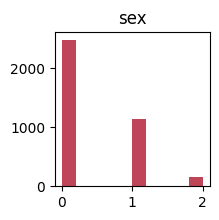

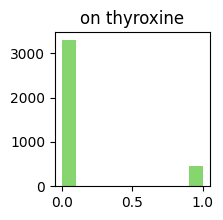

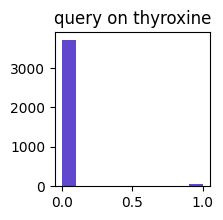

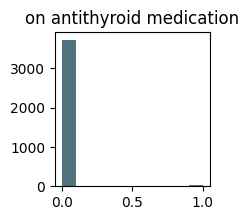

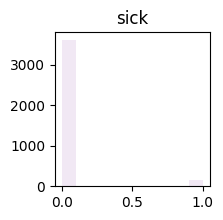

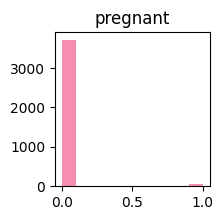

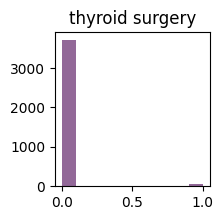

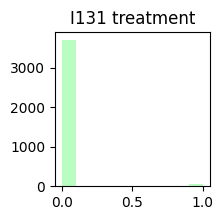

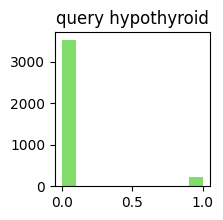

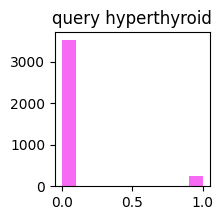

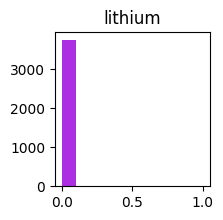

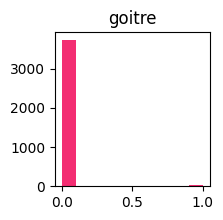

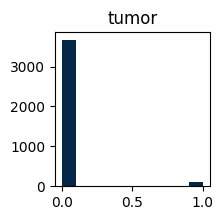

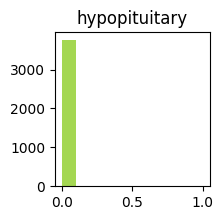

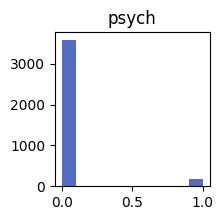

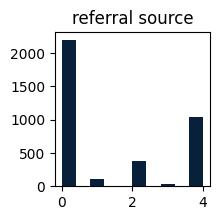

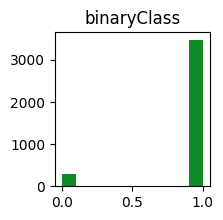

In [107]:


for row, i in enumerate(column_letters, start=1):
    colors = "#{:06x}".format(random.randint(0, 0xFFFFFF)) 
    plt.figure( figsize=(2,2))
    plt.hist(data[i], color=colors)
    plt.title(i)

plt.show

#### Finalizada essa etapa, conclui-se o tratamento de dados e inicia-se a análise das relações entre as variáveis.

## Correlação das variáveis

#### O projeto tem como objetivo criar um modelo de predição para hipertiroidismo, o que significa que a variável alvo, target, é a categoria "query hyperthyroid".

Para criar o modelo é importante compreender as relação de dependências entre as variáveis explicativas ("features") e a variável alvo. Um maneira de analisar isso é pela correlação da variável alvo com as demais. O mapa de cor a seguir mostra os resultados em ordem decrescento do módulo da correlação.

A correlação para cada uma das duas bases tratadas (data e data_t) diferem entre si. 

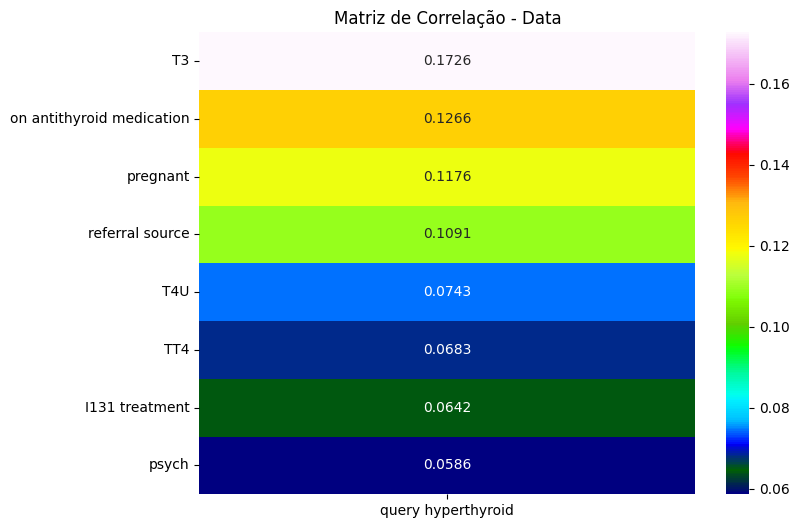

In [32]:
correlation_matrix = data.select_dtypes(include=['number']).corr()

correlation_matrix_filter = correlation_matrix[correlation_matrix['query hyperthyroid']==1]

plt.figure(figsize=(8, 6))
sns.heatmap(abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid',ascending=False).iloc[range(1,9)], annot=True, cmap='gist_ncar', fmt=".4f", annot_kws={"size": 10})
plt.title('Matriz de Correlação - Data')
plt.show()

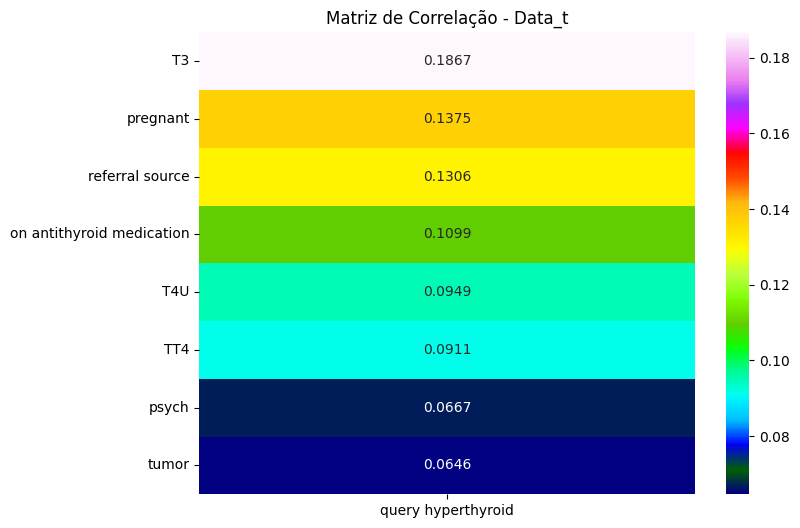

In [33]:
correlation_matrix_t = data_t.select_dtypes(include=['number']).corr()

correlation_matrix_filter_t = correlation_matrix_t[correlation_matrix_t['query hyperthyroid']==1]

plt.figure(figsize=(8, 6))
sns.heatmap(abs(correlation_matrix_filter_t.T).sort_values(by='query hyperthyroid',ascending=False).iloc[range(1,9)], annot=True, cmap='gist_ncar', fmt=".4f", annot_kws={"size": 10})
plt.title('Matriz de Correlação - Data_t')
plt.show()

As variáveis que mais influenciam a variável alvo para cada uma das bases são:

In [34]:
correlation_matrix_t = data_t.select_dtypes(include=['number']).corr()
correlation_matrix_filter_t = correlation_matrix_t[correlation_matrix_t['query hyperthyroid']==1]

print('Para a primeira base, data, as variáveis que mais influenciam a variável alvo são:\n')
print(f'{abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid', ascending=False).iloc[[1,2,3,4]]}\n\n')
print('Já para a segunda, data_t, as variáveis que mais influenciam a variável alvo são:\n')
print(f'{abs(correlation_matrix_filter_t.T).sort_values(by='query hyperthyroid', ascending=False).iloc[[1,2,3,4]]}')


Para a primeira base, data, as variáveis que mais influenciam a variável alvo são:

                           query hyperthyroid
T3                                   0.172649
on antithyroid medication            0.126566
pregnant                             0.117605
referral source                      0.109090


Já para a segunda, data_t, as variáveis que mais influenciam a variável alvo são:

                           query hyperthyroid
T3                                   0.186714
pregnant                             0.137482
referral source                      0.130627
on antithyroid medication            0.109926


#### A análise da correlação pode ser usada para determinar a exclusão de algumas variáveis, especialmente se elas apresentarem uma correlação muito inferior as demais.

As variáveis com menor correlção, com valores abaixo de 0,01, são 'TSH' e 'hypopituitary'. Seu baixo valor poderia ser um argumento para seu descarte. Contudo, apesar desse resultado, ambas podem ser relevantes na predição de hipertiroidismo. O "TSH" possui relação indireta com a alteração de hormônios, enquanto o 'hypopituitary' é uma condição que não ocorre com frequência, mas deve ser considereda mesmo assim. Por esse motivo, optou-se por não descrtar nenhuma variável.  

In [35]:
print('Correalções mais baixas:\n')
print(f'{abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid', ascending=True).round(4)}')

Correalções mais baixas:

                           query hyperthyroid
TSH                                    0.0017
hypopituitary                          0.0042
query on thyroxine                     0.0109
FTI                                    0.0109
binaryClass                            0.0134
lithium                                0.0138
thyroid surgery                        0.0155
query hypothyroid                      0.0195
on thyroxine                           0.0238
goitre                                 0.0247
sick                                   0.0352
age                                    0.0388
tumor                                  0.0553
sex                                    0.0576
psych                                  0.0586
I131 treatment                         0.0642
TT4                                    0.0683
T4U                                    0.0743
referral source                        0.1091
pregnant                               0.1176
on antit



#### As mesmas quatro variáveis estão no topo, com um diferente ordenamento e diferentes valores. O fato do valor total da correlação variar pouco é um indicativo de que não há grandes diferenças entre as bases. Por esse motivo, optou-se por aplciar os modelos apenas na base data, por ser maior. Em um caso real, é sugerido que o desenvolvimento dos modelos com as duas bases.

## Treinamento do modelo

Terimanada as análises e tratamento, pode-se iniciar a preparação dos dados para o treinamento de máquina, o que pode também ser considerada uma estapa de pré-processamento. Os métodos aplicados independem, de maneira geral, dos modelos a serem escolhidos. Por isso, podem ser desenvolvidos antes do treinamento.

#### Separação das variáveis explicativas (features) e alvo (targer):

In [36]:
x_o = data.drop('query hyperthyroid', axis = 1)
y_o = data['query hyperthyroid']
# x_o = data_t.drop('query hyperthyroid', axis = 1)
# y_o = data_t['query hyperthyroid']

## Faltou normalizar

In [ ]:
smote = SMOTE(random_state=42)
x, y = smote.fit_resample(x_o, y_o)
scaler = StandardScaler()
x = scaler.fit_transform(x)

#### Análise de Componentes Principais (PCA)

A Análise de Componentes Principais (PCA) é uma técnica que identifica as principais componentes, variáveis, que influenciam, determinam, o resultado da variável alvo. As componentes são o resultado da combinação linear das variáveis originais que formam as bases ortoganais que descrevem as variáveis explicativas. As principais componentes são aquelas que mais contribuem na formação das variáveis explicativas. Essa metodologia tem como objetivo diminuir a complexidade dos dados, pois diminui o número de campos ao excluir aqueles com menor peso na contribuição..

O gráfico de variância explicada acumulada por componente, a seguir, indica quanto do comportamento da base de dados pode ser explicada a cada novo componente que se adiciona.

In [ ]:
pca = PCA(n_components=  22 )
pca.fit(x)

In [ ]:
# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_
# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

# Plotando a variância explicada acumulada
df_pca = pd.DataFrame({
    'n_components': range(1, len(cumulative_variance) + 1),
    'cumulative_variance': cumulative_variance})

fig = px.line(df_pca, x='n_components', y='cumulative_variance',
    markers=True, title='Variância Explicada Acumulada por Componente',
    labels={'n_components': 'Número de Componentes', 'cumulative_variance': 'Variância Explicada Acumulada'})
fig.update_layout(xaxis=dict(dtick=1, tickmode='linear', range=[1, len(cumulative_variance)]),
                  yaxis=dict(range=[0, 1]))
fig.show()


Cada componente, indicado no eixo x, é uma combinação linear das categorias da base. O gráfico indica que são necessárias apenas 4 componentes para explicar na totalidade, y = 1, os dados.

Ao escolher descrever a base com 4 componentes, não se está excluindo as demais variáveis. Cada uma dessas componentes tem coeficientes que dão um peso de imporância para cada variável. Cada coeficiente desses múltiplica uma categoria de análise diferente da nossa base.

Para aplicar o PCA não é necessário saber a relação entre esses coeficientes e suas categorias, mas é interessante analisar sua relação para compreender o método.
Abaixo estão os coeficiente de cada variável para as três componentes principais. Em seguida, os coeficientes das quatro variáveis com maiores valores de correlação.

In [ ]:
# Organiza os componentes principais em um DataFrame
componentes = pd.DataFrame(pca.components_, columns=data.columns.drop('query hyperthyroid'))
abs(componentes.loc[[0,1,2]])

In [ ]:
componentes[['T3', 'on antithyroid medication', 'pregnant', 'referral source']].iloc[[0,1,2]]

In [ ]:
componentes.iloc[[0]].T.sort_values(by=0,ascending=False).T

In [ ]:
componentes.iloc[[1]].T.sort_values(by=1,ascending=False).T

In [ ]:
componentes.iloc[[2]].T.sort_values(by=2,ascending=False).T

É interessante perceber que as variáveis com maior correlação com a variável alvo não são, necessariamente, aquelas com maior peso no PCA. Isso ocorre porque essa técnica busca a 'correlação' combinada delas, e não isolada. Isso permite que ela diminua a complexidade do modelo sem, com isso, perder a contribuição de variáveis menos impactantes, mas importantes.

#### Dando continuidade à técnica, após a análise do gráfico e identificação do número de componentes, cria-se o modelo PCA com as principais componentes.

In [ ]:
pca_4 = PCA(n_components=4)
x_pca = pca_4.fit_transform(x)

#### Cross validation

#### Paralelamente, devido a complexidade dos dados, serão aplicados a eles a técnica de cross validation.

Essa técnica é usada em modelos complexos ou pequenos conjuntos de dados, como neste projeto. Ela compara o modelo treinado para diferentes distribuiçãos de bases de teste e treino, permitindo uma avaliação mais robusta. Ele faz um uso eficiente dos dados, em que todos os dados disponíveis são utilizados tanto para treino quanto para teste, em diferentes iterações.
A base do cross validation é criada, mas sua aplicação só ocorreno treinamento dos modelos.

In [ ]:
folds = 7   
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=5)


## Seleção dos modelos

A principal preocupação deste projeto é minimizar os falsos negativos. Em qualquer problema de saúde, minimizar os falsos negativos é crucial, pois significa garantir que os casos reais da doença, o hipertiroidismo, não sejam perdidos durante a predição. Um falso negativo em um diagnóstico de hipertiroidismo pode levar a complicações sérias, comprometendo a saúde do paciente. Portanto, a avaliação dos modelos deve incluir não apenas a precisão, mas também métricas que considerem a sensibilidade e o recall.

Para embasar a escolha, uma pequena tabela comparativa foi criada, incluindo os principais métodos trabalhados no curso.

| Modelo                | Justificativa                                                                                     |
|-----------------------|--------------------------------------------------------------------------------------------------|
| **XGBoost**           | Implementa gradiente boosting, conhecido por sua alta precisão em tarefas de classificação. Ele é especialmente eficiente em lidar com dados desbalanceados e tem opções que minimizam falsos negativos.        |
| **Random Forest**     | Utiliza várias árvores de decisão para realizar classificações. Por ser um modelo ensemble, o Random Forest é robusto contra o sobreajuste (overfitting) e oferece boa generalização, ajudando a melhorar a identificação de casos positivos. |
| **SVM** | Ideal para problemas de alta dimensionalidade, o SVM pode lidar com binários e multiclasse de forma eficaz, utilizando diferentes kernels para classificar os dados, o que pode ser benéfico na minimização de falsos negativos. |
| **Árvore de Decisão** | As árvores de decisão são intuitivas e fáceis de interpretar. Elas podem capturar relações não-lineares nos dados, embora sejam propensas a sobreajuste.|
| **Regressão Logística** | Um modelo estatístico utilizado principalmente para problemas binários, mas pode ser estendido para casos multiclasse.|
| **Regressão Polinomial** | Embora usualmente aplicada para regressão, a técnica pode ser adaptada para problemas de classificação. Contudo, a complexidade interpretativa e o risco de sobreajuste requerem atenção cuidadosa. |
| **Naive Bayes**       | É eficiente e rápido, adequado para classificações, especialmente em conjuntos de dados grandes. Embora presuma a independência entre as características, pode ainda fornecer boas estimativas em casos práticos. |
| **K-Means**           | Trata-se de um algoritmo de agrupamento, não especificamente de classificação. Pode ser útil na exploração inicial de dados, mas não deve ser utilizado como modelo de predição direta. |
| **Regressão Linear**  | Este modelo não é apropriado para problemas de classificação, visto que é mais focado em previsões numéricas. Usá-lo para classificação pode resultar em interpretações errôneas. |


A partir desse resumo, fica fácil entender por que os modelos escolhidos foram o **Xboost**, **Random Forest** e **SVM**.

Para cada modelo, é importante também o **ajuste dos hiperparâmetros**. Isso garante que o modelo não apenas se ajuste bem ao treinamento, mas também seja capaz de generalizar para novos dados.

## Xboost - ALgo está dando errado aqui, avaliar

cross validation aplicado diretamente ali ó

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV #cross validation aqui

In [ ]:
param_grid_xgboost = {
    'max_depth': [3, 5, 7],              
    'n_estimators': [50, 100, 200]       
}

xgboost = xgb.XGBClassifier()

grid_search_xgboost = GridSearchCV(
    estimator = xgboost,   
    param_grid=param_grid_xgboost,
    cv=crossvalidation
)


In [ ]:
# x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.5, random_state=42, stratify=y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42)

grid_search_xgboost.fit(x, y)

# Melhor Modelo
best_xgb = grid_search_xgboost.best_estimator_
print("Melhores parâmetros:", grid_search_xgboost.best_params_)
print("Melhor score (CV):", grid_search_xgboost.best_score_)


In [ ]:
# predições no conjunto de teste
y_pred_xgb = best_xgb.predict(x_test)

In [ ]:
# métricas de avaliação
acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
print(f"Acurácia: {acc_xgb:.4f}")
print(f"Recall: {rec_xgb:.4f}")
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
print(f"Precisão: {prec_xgb:.4f}")
print(f"F1 score: {f1_xgb:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)

comentário

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [ ]:
params_grid_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10)
}

randomforest = RandomForestClassifier(random_state=42)

rf = RandomizedSearchCV(
    estimator= randomforest,
    param_distributions= params_grid_rf,
    n_iter=100,  
    random_state=42,
    cv = crossvalidation,
    n_jobs=-1  )

rf.fit(x, y)
# rf.fit(x_train, y_train)

best_params_rf = rf.best_params_
print("Melhores Parâmetros Encontrados:", best_params_rf)

# Fazendo previsões no conjunto de teste
y_pred_rf = rf.predict(x_test)

In [ ]:
# métricas de avaliação
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
print(f"Acurácia: {acc_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
print(f"Precisão: {prec_rf:.4f}")
print(f"F1 score: {f1_rf:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)

## SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(random_state = 1, C = 1.0)

param_grid_SVM = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

grid_search_svm = GridSearchCV(estimator= svm_model,
                           param_grid=param_grid_SVM,
                           scoring='accuracy',
                           cv=crossvalidation,
                           verbose=2,
                           n_jobs=-1)

grid_search_svm.fit(x, y)

best_params_svm = grid_search_svm.best_params_
best_svm_model = grid_search_svm.best_estimator_

print(best_params_svm)
print(best_svm_model)
svm_model.fit(x,y)
y_pred_svm = svm_model.predict(x_train)

In [ ]:
# métricas de avaliação
acc_svm = accuracy_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
print(f"Acurácia: {acc_svm:.4f}")
print(f"Recall: {rec_svm:.4f}")
prec_svm= precision_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)
print(f"Precisão: {prec_svm:.4f}")
print(f"F1 score: {f1_svm:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

## Avaliação



2. **Métricas de Avaliação**: Além da acurácia, o foco deve ser em métricas específicas, como sensibilidade (ou recall), precisão e a pontuação F1. Essas métricas fornecem uma visão mais clara da performance do modelo em identificar casos positivos.

3. **Interpretação dos Resultados**: Docentes e profissionais de saúde devem estar envolvidos na interpretação dos resultados, para garantir que os insights derivados dos modelos sejam aplicáveis na prática e em conformidade com os protocolos clínicos.

Estas diretrizes abrangem a seleção de modelos de predição para hipertiroidismo, garantindo que pacientes em risco sejam adequ

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import ConfusionMatrixDisplay


## Comunicação dos resultado